P84 20 Hazard Map for EGU or PhD Defense Slides

xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 579439
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.


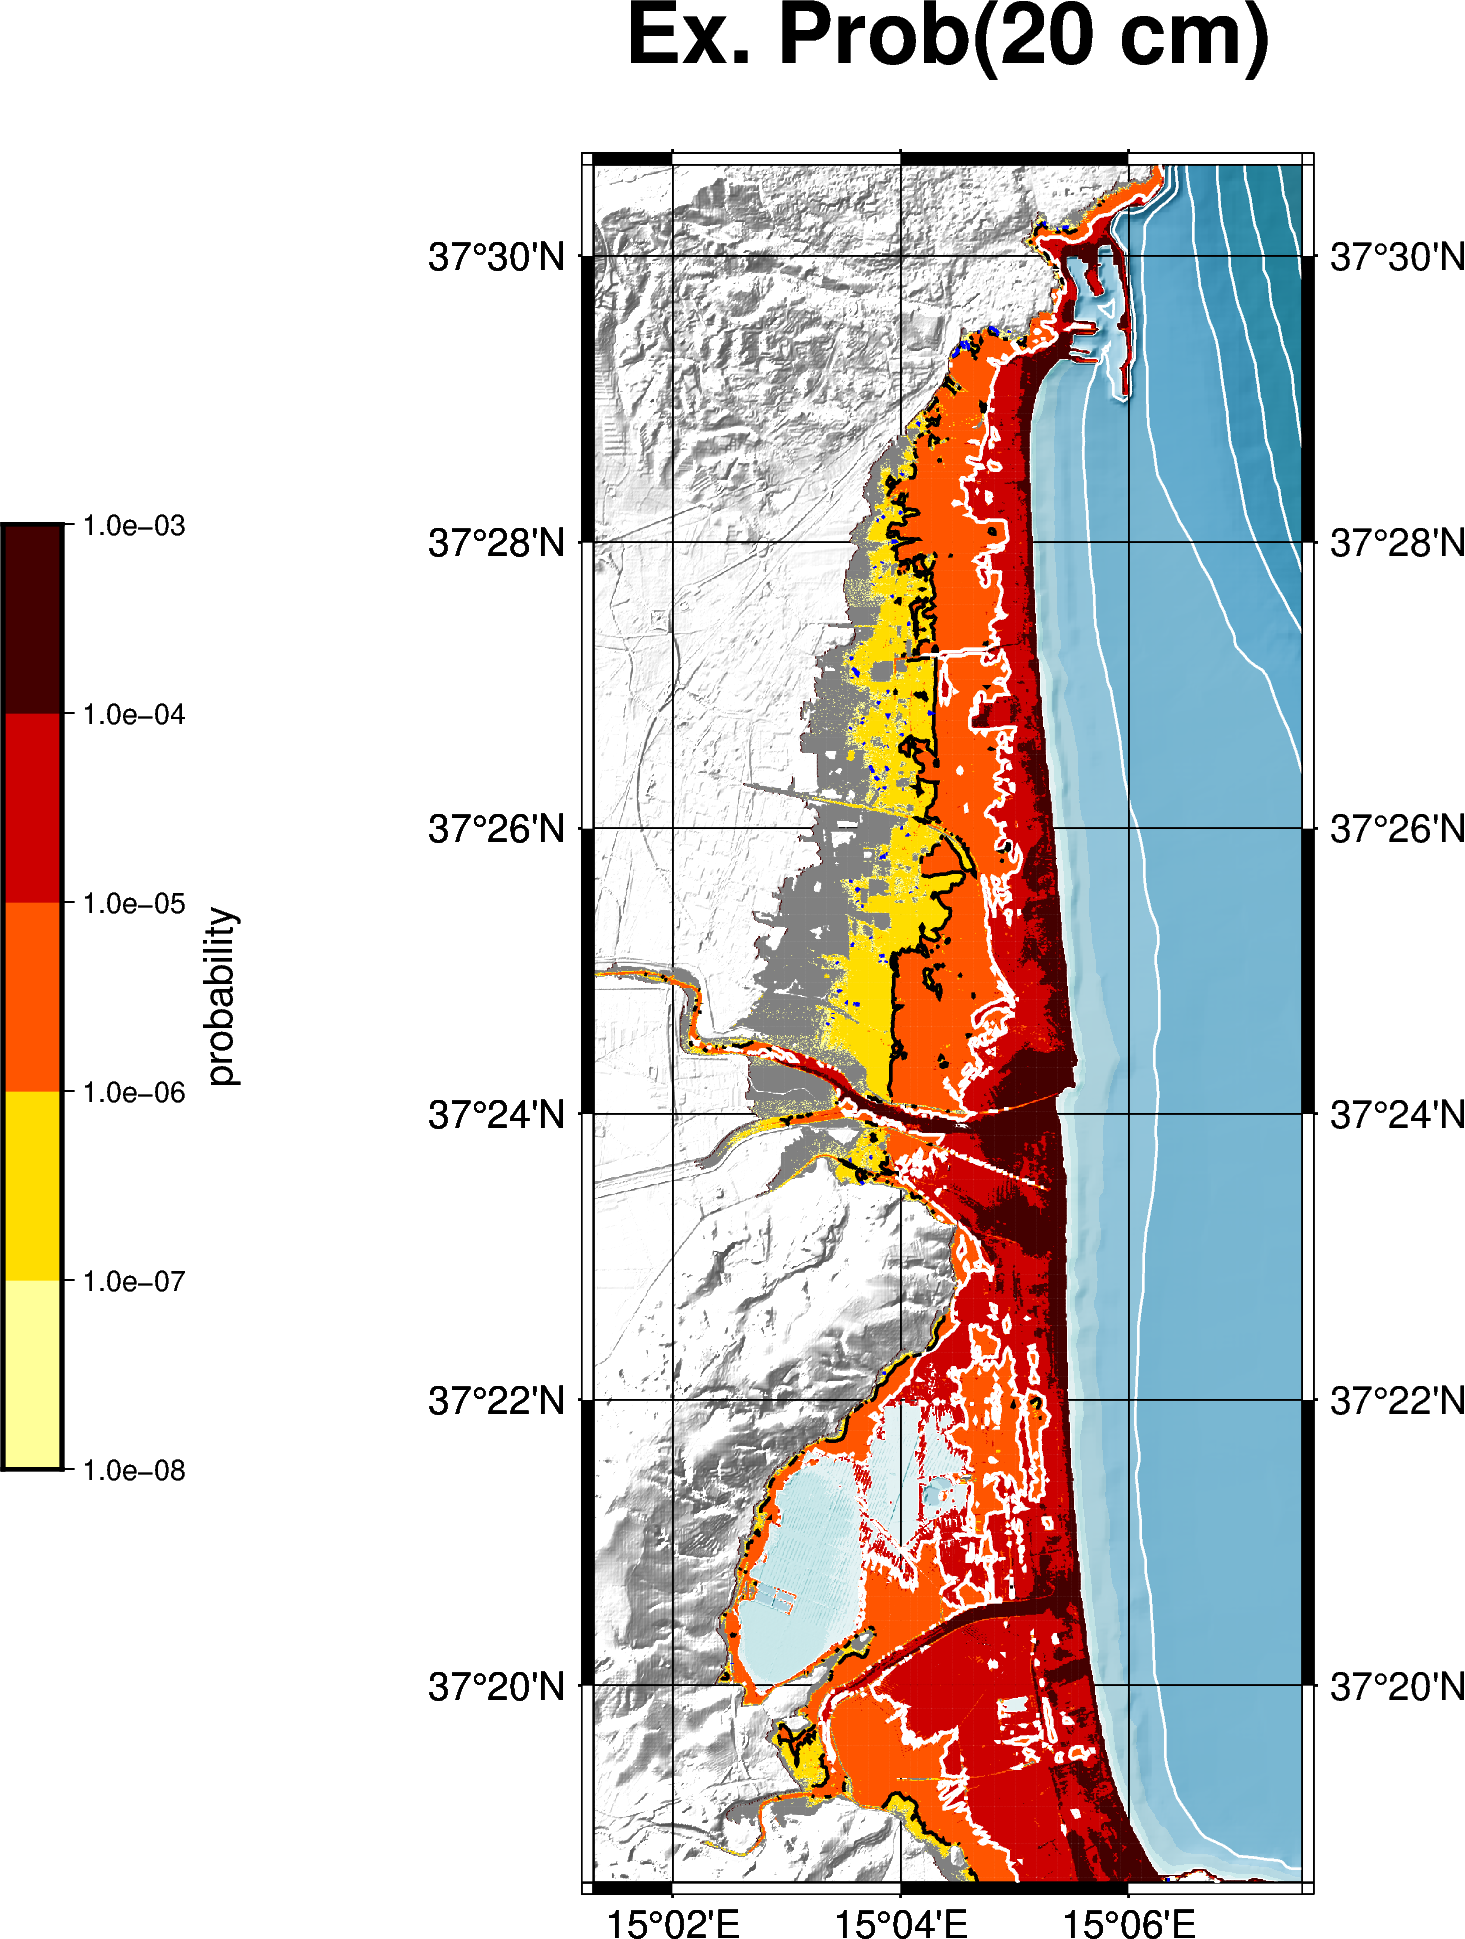

In [12]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['529']   
columnname = str(38)
mask_size = '892'
train_size = list_size[0]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

grid_CT_P1 = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2_topo_test.nc',engine='netcdf4')
temp = grid_CT_P1['r2topo']
temp = temp.where(temp>0,0)
grid_CT_P1['r2topo'] = temp

# Plot grid
fig = pygmt.Figure()

with fig.subplot(
        nrows=1,
        ncols=1,
        subsize = ["8","20c"],
        sharey = True,
        frame = ["ag"],
        clearance  = "w4.5c",
        ):
    with fig.set_panel(0):
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tEx. Prob(20 cm)"])
        fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2only.cpt'
        cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background='white')
        idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_1658_PSHalf.txt', sep=",")
        ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')
        #replace 0 with nan
        ex_rate[ex_rate == 0] = np.nan
        fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,0],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
        grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate[:,0], spacing='1s', region=[xmin,xmax,ymin,ymax])
        # fig.grdimage(grid_rate, cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"])
        fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c')
        fig.colorbar(frame=["x+lprobability"], position="JML+o4.5c/-2.5c+w8c/0.5c+m", log = True)  
fig.show()

#save as csv 
table = pd.DataFrame({'lon': idx_val['lon'], 'lat': idx_val['lat'], 'ex_rate': ex_rate[:,0]})
table.to_csv(f'//mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/PTHA/ex_rate_{train_size}.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['225', '529','892','1658','3454','7071']   
columnname = str(38)
mask_size = '892'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('../../../data/processed/CT_defbathy.nc',engine='netcdf4')

#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

Depth_list = [20,100,300,500,1000] 

for d,depth in enumerate(Depth_list):
    # Plot grid
    fig = pygmt.Figure()

    with fig.subplot(
            nrows=3,
            ncols=1,
            subsize = ["8","17c"],
            sharey = True,
            frame = ["ag"],
            clearance  = "w4.5c",
            ): 
        with fig.set_panel(panel=[0,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate[:,d], spacing='1s', region=[xmin,xmax,ymin,ymax])
            # fig.grdimage(grid_rate, cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"])
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
        with fig.set_panel(panel=[1,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_1658.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
        with fig.set_panel(panel=[2,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_CT['z'], levels=25, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/sis_PTHArate_{train_size}.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
    #save
    savefile = f'./PTHA_{train_size}_{reg}_ProEx_{depth}.png'
    fig.savefig(savefile,dpi=300)
    fig.show()

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'SR'
list_size = ['228', '550' ,'961','1773','3669','6941']
columnname = str(54)
mask_size = '961'
train_size = list_size[3]

# Load the elevation from netcdf grid
grid_SR = xr.open_dataset('../../../data/processed/SR_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_SR['y'].min().values
ymax = grid_SR['y'].max().values
xmin = grid_SR['x'].min().values
xmax = grid_SR['x'].max().values

Depth_list = [20,100,300,500,1000] 

for d,depth in enumerate(Depth_list):
    # Plot grid
    fig = pygmt.Figure()
    with fig.subplot(
            nrows=3,
            ncols=1,
            subsize = ["6","5.5c"],
            sharey = True,
            frame = ["ag"],
            clearance  = "w4.5c",
            ): 
        with fig.set_panel(panel=[0,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_SR['z'], levels=25, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/true_PTHArate_53550.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate[:,d], spacing='1s', region=[xmin,xmax,ymin,ymax])
            # fig.grdimage(grid_rate, cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"])
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
            # fig.colorbar(frame=["x+lprobability"], log = True,position="JBC+o0/5c+w10c/0.5c+h")
            # fig.savefig(f'./plots/ProExG_colorbarHorizontal.png',dpi=300)
        with fig.set_panel(panel=[1,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_SR['z'], levels=25, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
        with fig.set_panel(panel=[2,0]):
            #basemap
            cptfile = './extra/bathy2.cpt'
            cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
            fig.grdimage(grid_SR['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c')
            fig.grdcontour(grid_SR['z'], levels=25, pen='0.5p,white', limit=[-100, 0],projection='M6c')
            #simulated hazard
            cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background=True)
            idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_{train_size}_PSHalf.txt', sep=",")
            ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/sis_PTHArate_{train_size}.npy')
            #replace 0 with nan
            # ex_rate[ex_rate == 0] = np.nan
            fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,d],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
            #contours from simulation hazard
            fig.grdcontour(grid_rate, levels=[1e-4], pen='0.75p,lightblue', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c',cut=10)
            fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c',cut=100)
            fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c',cut=100)
    #save
    savefile = f'./PTHA_{train_size}_{reg}_ProEx_{depth}.png'
    fig.savefig(savefile,dpi=300)
    fig.show()

Hazard Curves at POIs

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from scipy.stats import norm

# Load file
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
reg = 'SR'

if reg == 'CT':
    columnname = str(38)
    list_size = ['225', '529','892','1658','3454','7071']  
elif reg == 'SR':
    columnname = str(54)
    list_size = ['228', '550' ,'961','1773','3669','6941']


def q_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        # fit a normal distribution
        # mu, std = norm.fit(data)
        mu = 0 
        std = np.sqrt(np.sum((data - mu) ** 2, axis=0) / (data.shape[0] - 1))
        qmin,qmax = norm.ppf(q1, loc=mu, scale=std), norm.ppf(q2, loc=mu, scale=std)
    return qmin, qmax,mu

def q_ltrunc_normal(data,q1,q2):
    if len(data) <= 1:
        qmin, qmax, mu = 0, 0, 0
    else:
        #fit a left truncated normal distribution
        mu, std = norm.fit(data)
        #truncated normal distribution
        a, b = (data.min() - mu), np.inf
        ltuncnorm = truncnorm(a, b, loc=mu, scale=std)
        qmin,qmax = ltuncnorm.ppf(q1), ltuncnorm.ppf(q2)
    return qmin, qmax, mu

def update_depths(depth_data,depth_bins,qmin_tab,qmax_tab):
    #for each depth bin, update the depth data as error corrected depth and +/- error
    depth_data_low = np.zeros_like(depth_data)
    depth_data_high = np.zeros_like(depth_data)

    for i in range(len(depth_bins)-1):
        
        #get the index of the data points in the bin
        index = np.where((depth_data >= depth_bins[i]) & (depth_data < depth_bins[i+1]))[0]
        
        # #get the qmin and qmax of the bin
        # print(depth_bins[i],qmin_tab[i],qmax_tab[i])

        qmin = qmin_tab[i]
        qmax = qmax_tab[i]

        # print(depth_bins[i],qmin,qmax)
    
        #update the depth data
        depth_data_low[index] = depth_data[index] + qmin
        depth_data_high[index] = depth_data[index] + qmax

    #if negative depths, set to 0
    depth_data_low[depth_data_low < 0] = 0
    return depth_data_low, depth_data_high 

def exceedance_curve(thresholds, max_stage_point, rates): 
   # Annual Mean Rate of threshold exceedance 
   lambda_exc = np.zeros((len(thresholds), 1000)) 
   for threshold in range(len(thresholds)): 
       ix = np.array(np.where(max_stage_point > thresholds[threshold])).squeeze() 
       for j in range(1000): 
           #for index in ix: 
           lambda_exc[threshold, j] = lambda_exc[threshold, j] +  rates[ix,j].sum(axis=0) 
   #------------------------------------------------ 
   return lambda_exc 

def single_exceedance_curve(thresholds, max_stage_point, rates): 
   # Annual Mean Rate of threshold exceedance 
   lambda_exc = np.zeros((len(thresholds), )) 
   for threshold in range(len(thresholds)): 
       ix = np.array(np.where(max_stage_point > thresholds[threshold])).squeeze() 
       #for index in ix: 
       lambda_exc[threshold] = lambda_exc[threshold] +  rates[ix].sum(axis=0) 
   #------------------------------------------------ 
   return lambda_exc

In [ ]:
#get rates
eve_rates = pd.read_csv(f'{MLDir}//data/info/event_rates_mean53550.csv')
rate = eve_rates['mean_prob'].values

#compute depth thresholds 
# thresholds_depth = np.linspace(0, 12, 5000)

thresholds_depth = np.array([2.000e-01,3.000e-01, 5.000e-01, 8.000e-01, 1.000e+00,
                             1.2500e+00,1.500e+00, 2.000e+00, 2.500e+00, 3.000e+00,
                            3.600e+00, 4,   4.320e+00, 4.5, 5.180e+00, 5.5, 6.220e+00,
                            7.460e+00, 8,  8.950e+00, 1.074e+01, 11, 1.289e+01,])


#colors for different tasks
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'crimson', 'darkblue', 'darkgreen', 'darkred', 'darkpurple', 'darkorange', 'darkbrown', 'darkpink', 'darkgray', 'darkolive', 'darkcyan', 'darkmagenta', 'darkyellow', 'darkcrimson']
styles = ['-', '--', ':', '-.', (0, (5, 10)), (0, (3, 1, 1, 1))]
labels = ['0.4%', '1.0%', '1.8%', '3.3%', '7.0%', '13%'] 
#iterate over points
for select_pt in range(1, 13):
    select_pt = str(select_pt)

    #plot exceedance curve below and misfit in bins of 5 subplots
    fig,ax = plt.subplots(1,1,figsize=(5,5))
    
    for s,train_size in enumerate(list_size[:]):
        eve_dep_task = pd.read_csv(f'{MLDir}/model/{reg}/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{train_size}_true_pred_er_combined.csv')
        
        #true
        if train_size == list_size[0]:
            true = eve_dep_task['T'+select_pt].values
            lambda_exc_true = single_exceedance_curve(thresholds_depth, true, rate)
            ax.plot(thresholds_depth,lambda_exc_true, label='100%', color='black', linewidth=3)
        
        #predicted
        pred = eve_dep_task['P'+select_pt].values
        lambda_exc_pred = single_exceedance_curve(thresholds_depth, pred, rate)
        ax.plot(thresholds_depth,lambda_exc_pred, label=labels[s], color=colors[s], linestyle=styles[0], alpha=0.7,linewidth=1.5)
        ax.set_xlabel('Depth')
        ax.set_ylabel('Exceedance rate')
        ax.set_yscale('log')
        minrate = np.max(lambda_exc_true)*10
        maxdepth = np.round(np.max(true))+2
        ax.set_xlim(0.5, maxdepth)
        ax.set_ylim(1e-8, minrate)

    #legend outside plot
    ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))
    # ax.text(5,0.0000001,f'Exceedance curve/misfit at site {select_pt}',)
    plt.savefig(f'./hazcurve_{reg}_PoI{select_pt}.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
